In [24]:
from pathlib import Path

import numpy as np
import xarray as xr
import pandas as pd

import scipy.stats as stats
import xskillscore as xs

import matplotlib as mpl
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

import xclimate as xclim

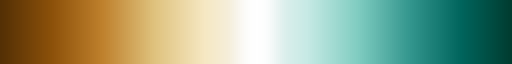

In [2]:
brbg = xclim.plot.cmap_smooth_center_color('BrBG')
brbg

In [3]:
## FHIST PPE

variables = [
    # 'PRECT_month_1',
    # 'TLAI_month_1',
    'PRECC_month_1',
    'PRECL_month_1',
]

time_slice = slice('1950-01', '2014-12')
year_start = time_slice.start[:4]
year_end = time_slice.stop[:4]
grid = xclim.load_fhist_ppe_grid()

snow_pct_threshold = 100    # maximum allowable percent of snow cover on all months of the average year, 100 = no mask
nonglc_pct_threshold = 100  # maximum allowable percent of glaciated land for a NON-glaciated gridcell, 100 = no mask

fsno = xclim.load_fhist('FSNO_month_1', keep_var_only=True)['FSNO'].sel(time=time_slice).reindex_like(grid, method='nearest', tolerance=1e-3)
fsno_clim_min = fsno.groupby('time.month').mean().min(dim='month')

# Create masks
nonglc_mask = grid.PCT_GLC <= nonglc_pct_threshold
full_mask = nonglc_mask
# snow_mask = fsno_clim_min <= (snow_pct_threshold / 100)
# full_mask = snow_mask & nonglc_mask

# Load output
fhist_full = {}
fhist_mean = {}
fhist_trend = {}
for v in variables:
    print(f'  {v}')
    name = '_'.join(v.split('_')[:-2])
    fhist_full[v] = xclim.load_fhist(v, keep_var_only=True)[name].sel(time=time_slice).reindex_like(grid, method='nearest', tolerance=1e-3)
    fhist_full[v] = fhist_full[v].where(full_mask).chunk({'time': -1})
    fhist_full[v].attrs['masks'] = f'gridcell percent glaciated land <= {nonglc_pct_threshold}'

# Monthly PRECT (PRECC + PRECL)
print("  PRECT_month_1")
fhist_full["PRECT_month_1"] = fhist_full["PRECC_month_1"] + fhist_full["PRECL_month_1"]
fhist_full["PRECT_month_1"] = fhist_full["PRECT_month_1"] * 86400 * 1000
fhist_full["PRECT_month_1"].attrs["long_name"] = "total monthly precipitation rate (PRECC + PRECL)"
fhist_full["PRECT_month_1"].attrs["units"] = "mm/day"
fhist_full.pop("PRECC_month_1")
fhist_full.pop("PRECL_month_1")

# Truncate the timeseries for analysis
fhist_mean = {}
fhist_trend = {}
for v in ['PRECT_month_1']:
    fhist_mean[v] = fhist_full[v].sel(time=slice('1995-01', '2014-12')).chunk({'time': -1})
    fhist_trend[v] = fhist_full[v].sel(time=slice('1980-01', '2014-12')).chunk({'time': -1})

  PRECC_month_1
  PRECL_month_1
  PRECT_month_1


In [15]:
pr_ens = fhist_mean['PRECT_month_1'].sel(member=slice(1,None)).persist()
pr_def = fhist_mean['PRECT_month_1'].sel(member=0).persist()
pr_delta = pr_ens - pr_def

pr_n_eff = xs.effective_sample_size(pr_ens, pr_def).compute()

In [ ]:
pr_t_stat = pr_delta.mean(dim='time') / (pr_delta.std(dim='time') / np.sqrt(pr_n_eff))

pr_p_value = 2.0 * (1.0 - stats.t.cdf(abs(pr_t_stat), pr_n_eff))
pr_p_value = xr.DataArray(
    pr_p_value,
    coords=pr_t_stat.coords,
    dims=pr_t_stat.dims,
)

pr_005fdr_p_value = xclim.multiple_testing.calculate_pval_fdr(pr_p_value, alpha_fdr=0.05)

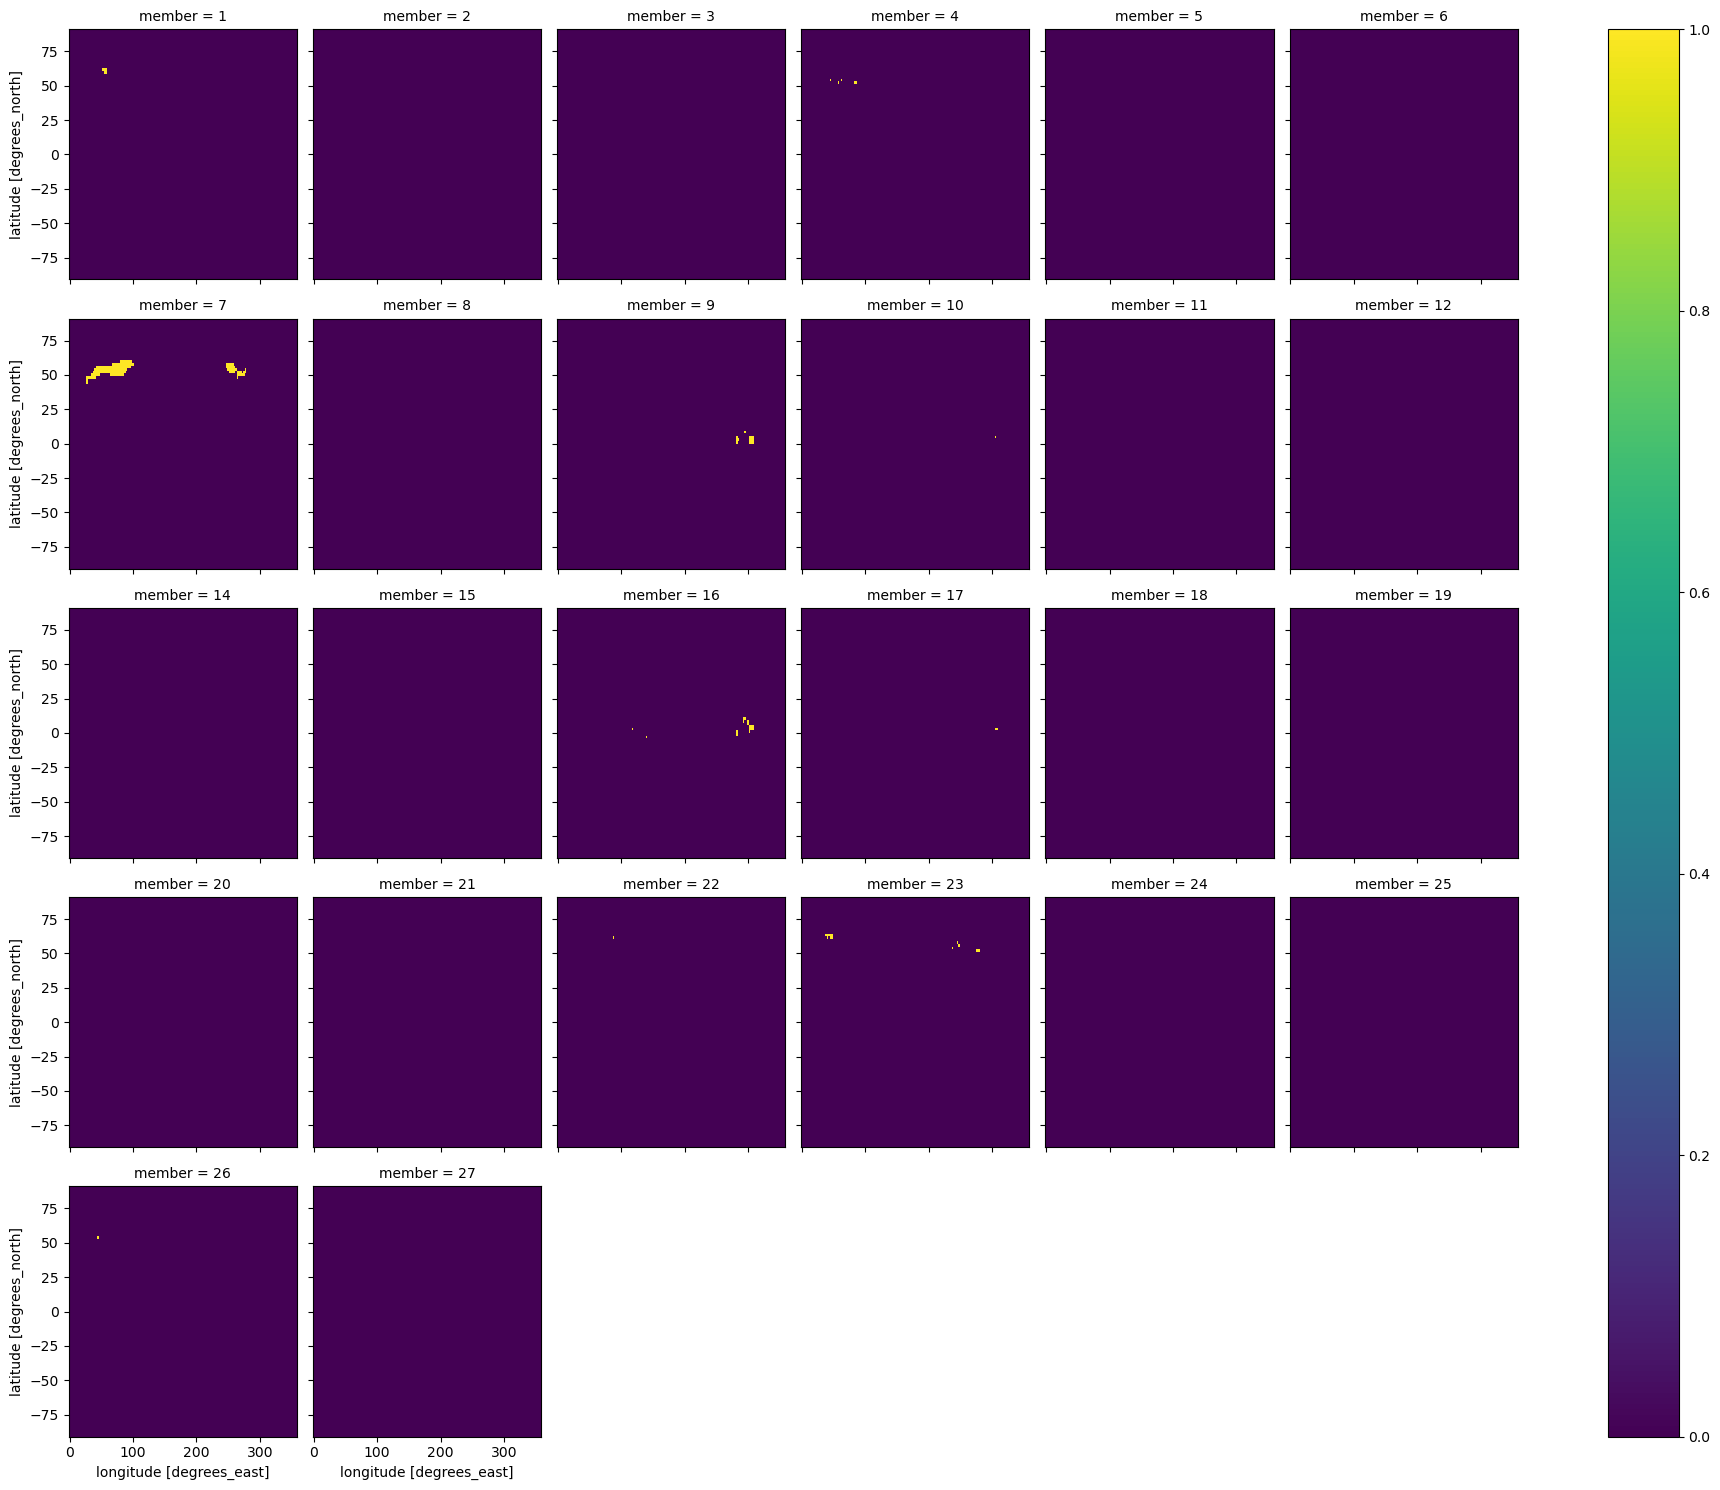

In [39]:
(pr_p_value < pr_005fdr_p_value).plot(col='member', col_wrap=6)

In [5]:
d_tm_pr = fhist_mean['PRECT_month_1'].sel(member=slice(1,None)).mean(dim='time') - fhist_mean['PRECT_month_1'].sel(member=0).mean(dim='time')

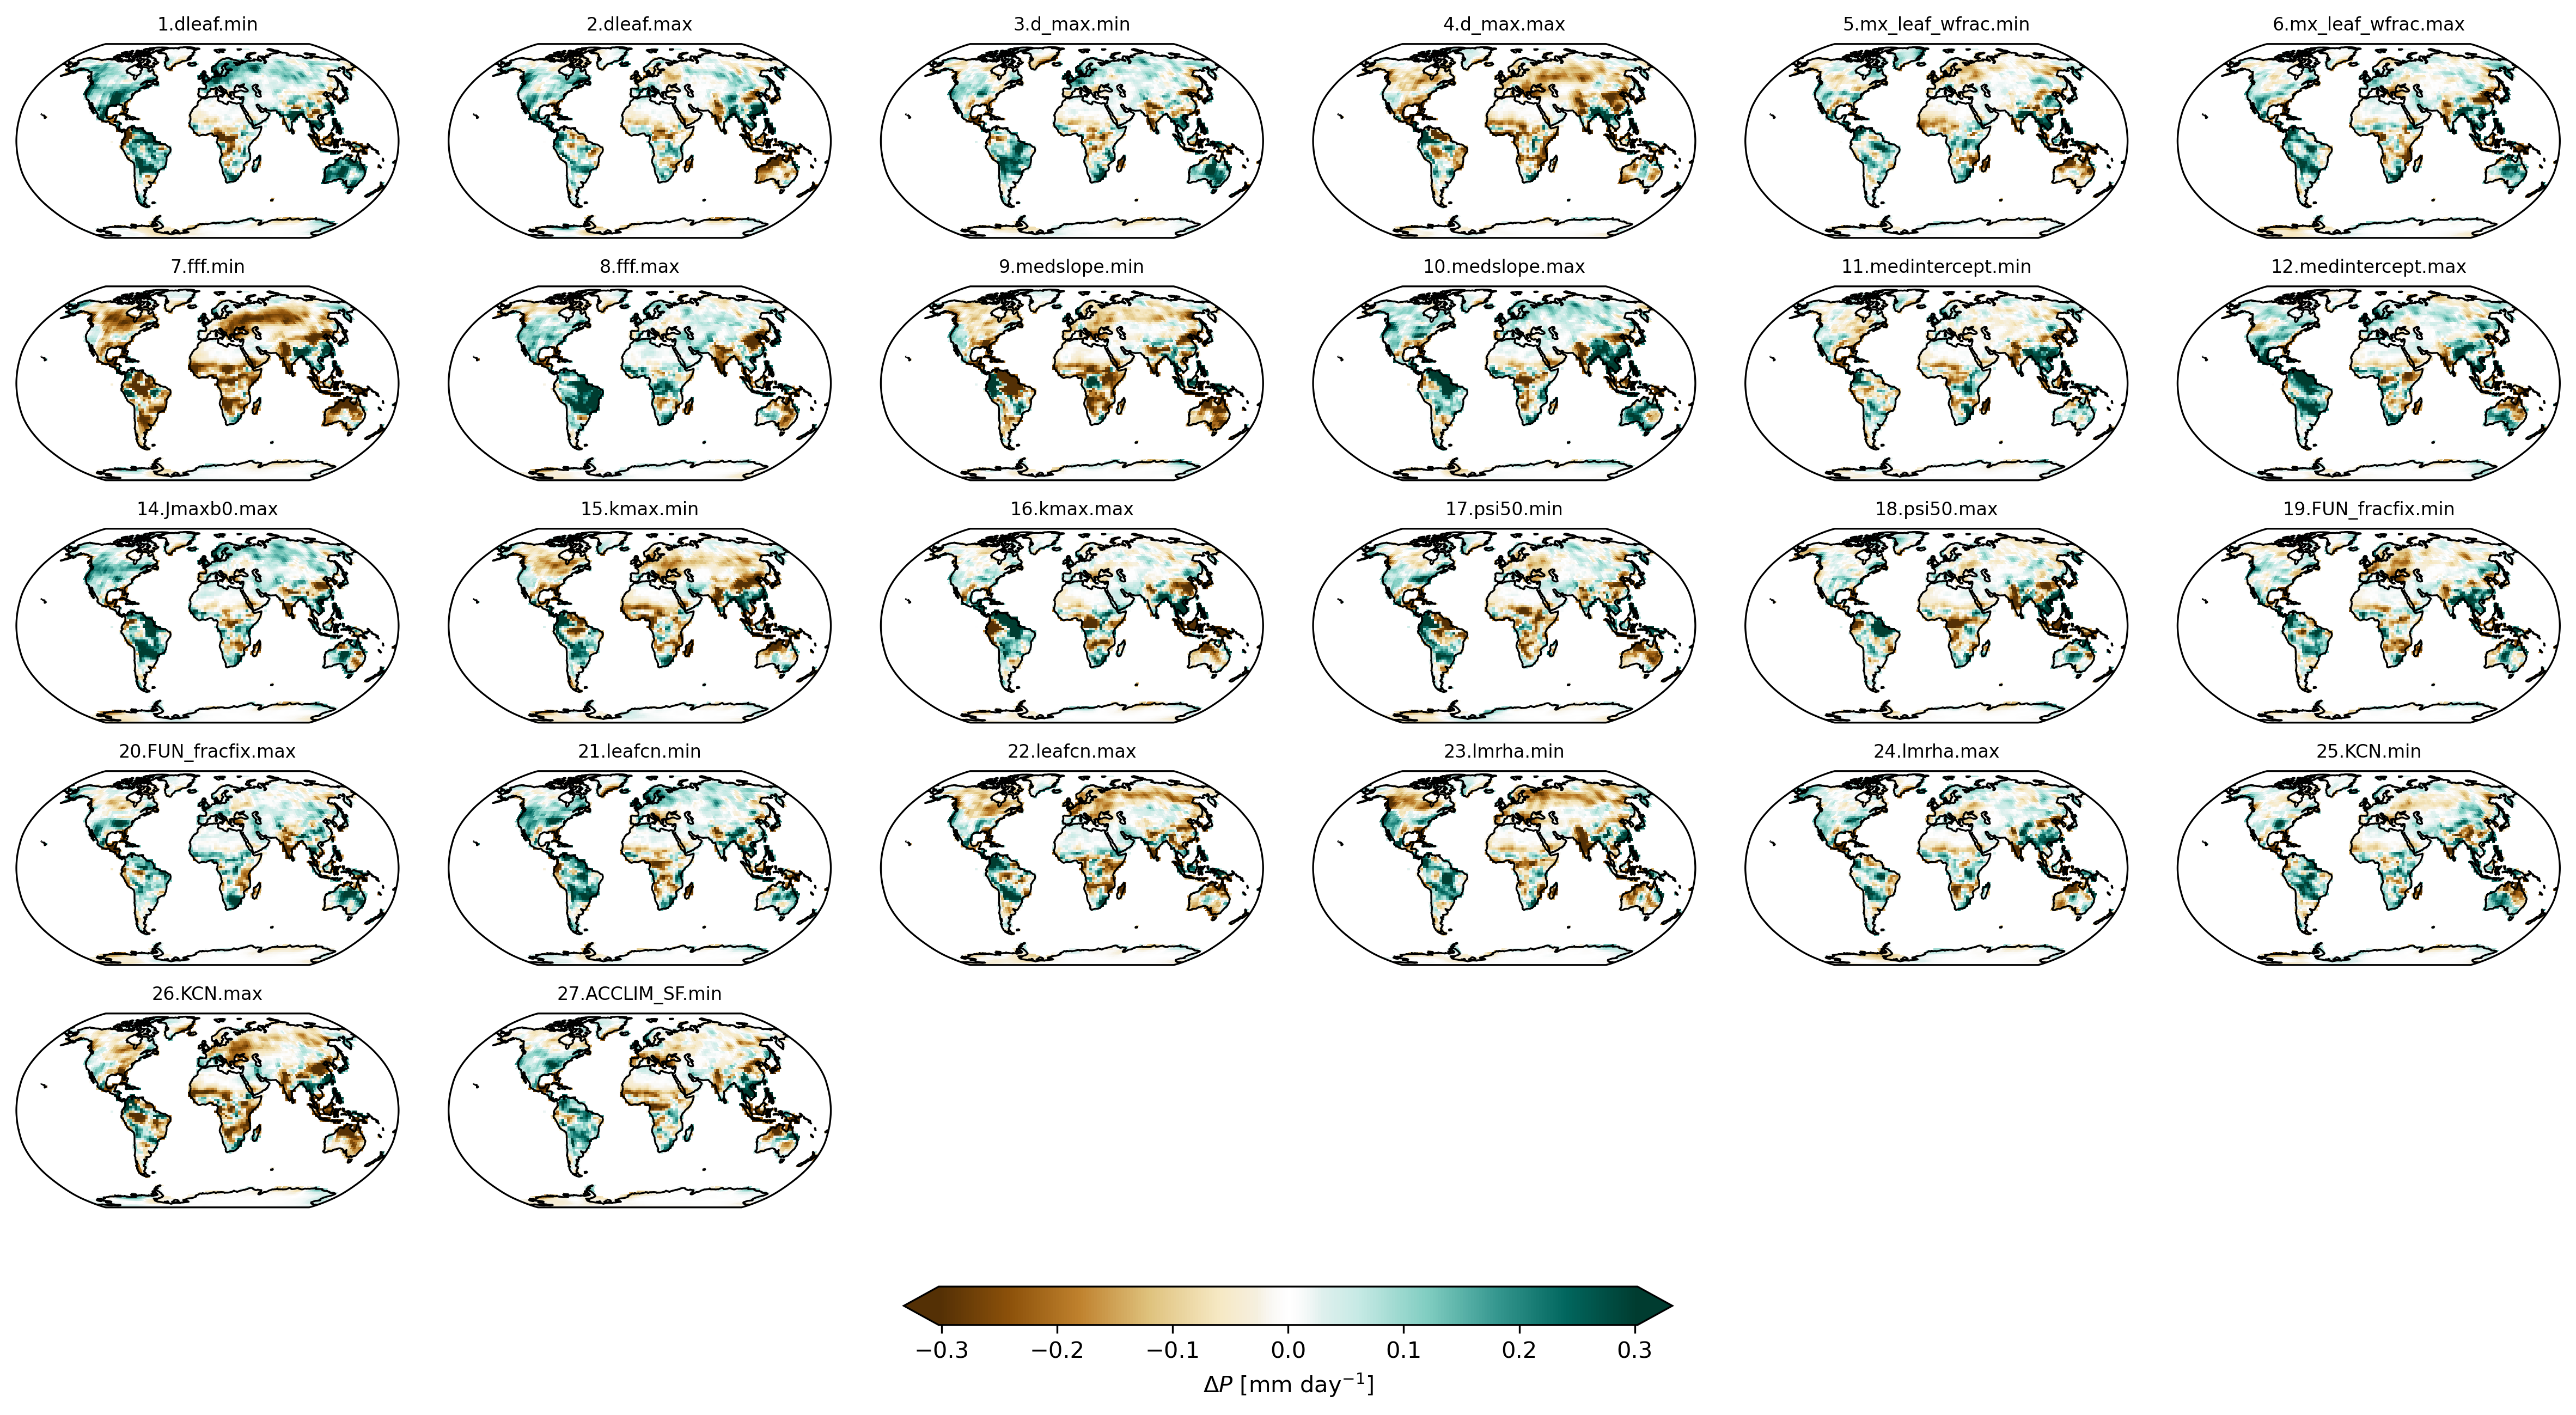

In [ ]:
fg = xclim.plot.plot_facetgrid_map(d_tm_pr, dim='member', label='$\\Delta P$ [mm day$^{-1}$]', cmap=brbg, robust=True)
fg.fig.set_dpi(300)

In [7]:
cluster_client = xclim.create_dask_cluster(
    account='UWAS0155',
    nworkers=2,
    ncores=1,
    nmem='16GB',
    walltime='02:00:00',
)

account:  UWAS0155
nworkers: 2
ncores:   1
nmemory:  16GB
walltime: 02:00:00
{'PBSCluster-1': <dask_jobqueue.pbs.PBSJob: status=running>, 'PBSCluster-0': <dask_jobqueue.pbs.PBSJob: status=running>}

To view the dask dashboard
Run the following command in your local terminal:
> ssh -N -L 8787:128.117.211.160:8787 bbuchovecky@casper.hpc.ucar.edu
Open the following link in your local browser:
> http://localhost:8787/status


In [40]:
xclim.close_dask_cluster(cluster_client)

In [9]:
pr_ts = fhist_full['PRECT_month_1']

pr_sc = pr_ts.groupby('time.month').mean()
pr_dsc = pr_ts.groupby('time.month') - pr_sc
pr_dsc = pr_dsc.chunk({'time': -1})

pr_ta = pr_ts.mean(dim='time')
pr_yr = pr_ts.groupby('time.year').mean() - pr_ta
pr_yr = pr_yr.chunk({'year': -1})

pr_dsc['time'] = pr_dsc.time.dt.year + (pr_dsc.time.dt.dayofyear - 1) / 365.25

pr_dsc = pr_dsc.persist()
pr_yr = pr_yr.persist()

In [44]:
pr_dsc_ols = xclim.regression.ols_field(pr_dsc.time, pr_dsc, sample_dim='time', alpha=0.05).compute()
pr_yr_ols = xclim.regression.ols_field(pr_yr.year, pr_yr, sample_dim='year', alpha=0.05).compute()

/glade/work/bbuchovecky/miniforge3/envs/data-sci-py312/lib/python3.12/site-packages/distributed/client.py:3387: UserWarning: Sending large graph of size 16.25 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(
/glade/work/bbuchovecky/miniforge3/envs/data-sci-py312/lib/python3.12/site-packages/distributed/client.py:3387: UserWarning: Sending large graph of size 16.28 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(
/glade/work/bbuchovecky/miniforge3/envs/data-sci-py312/lib/python3.12/site-packages/distributed/client

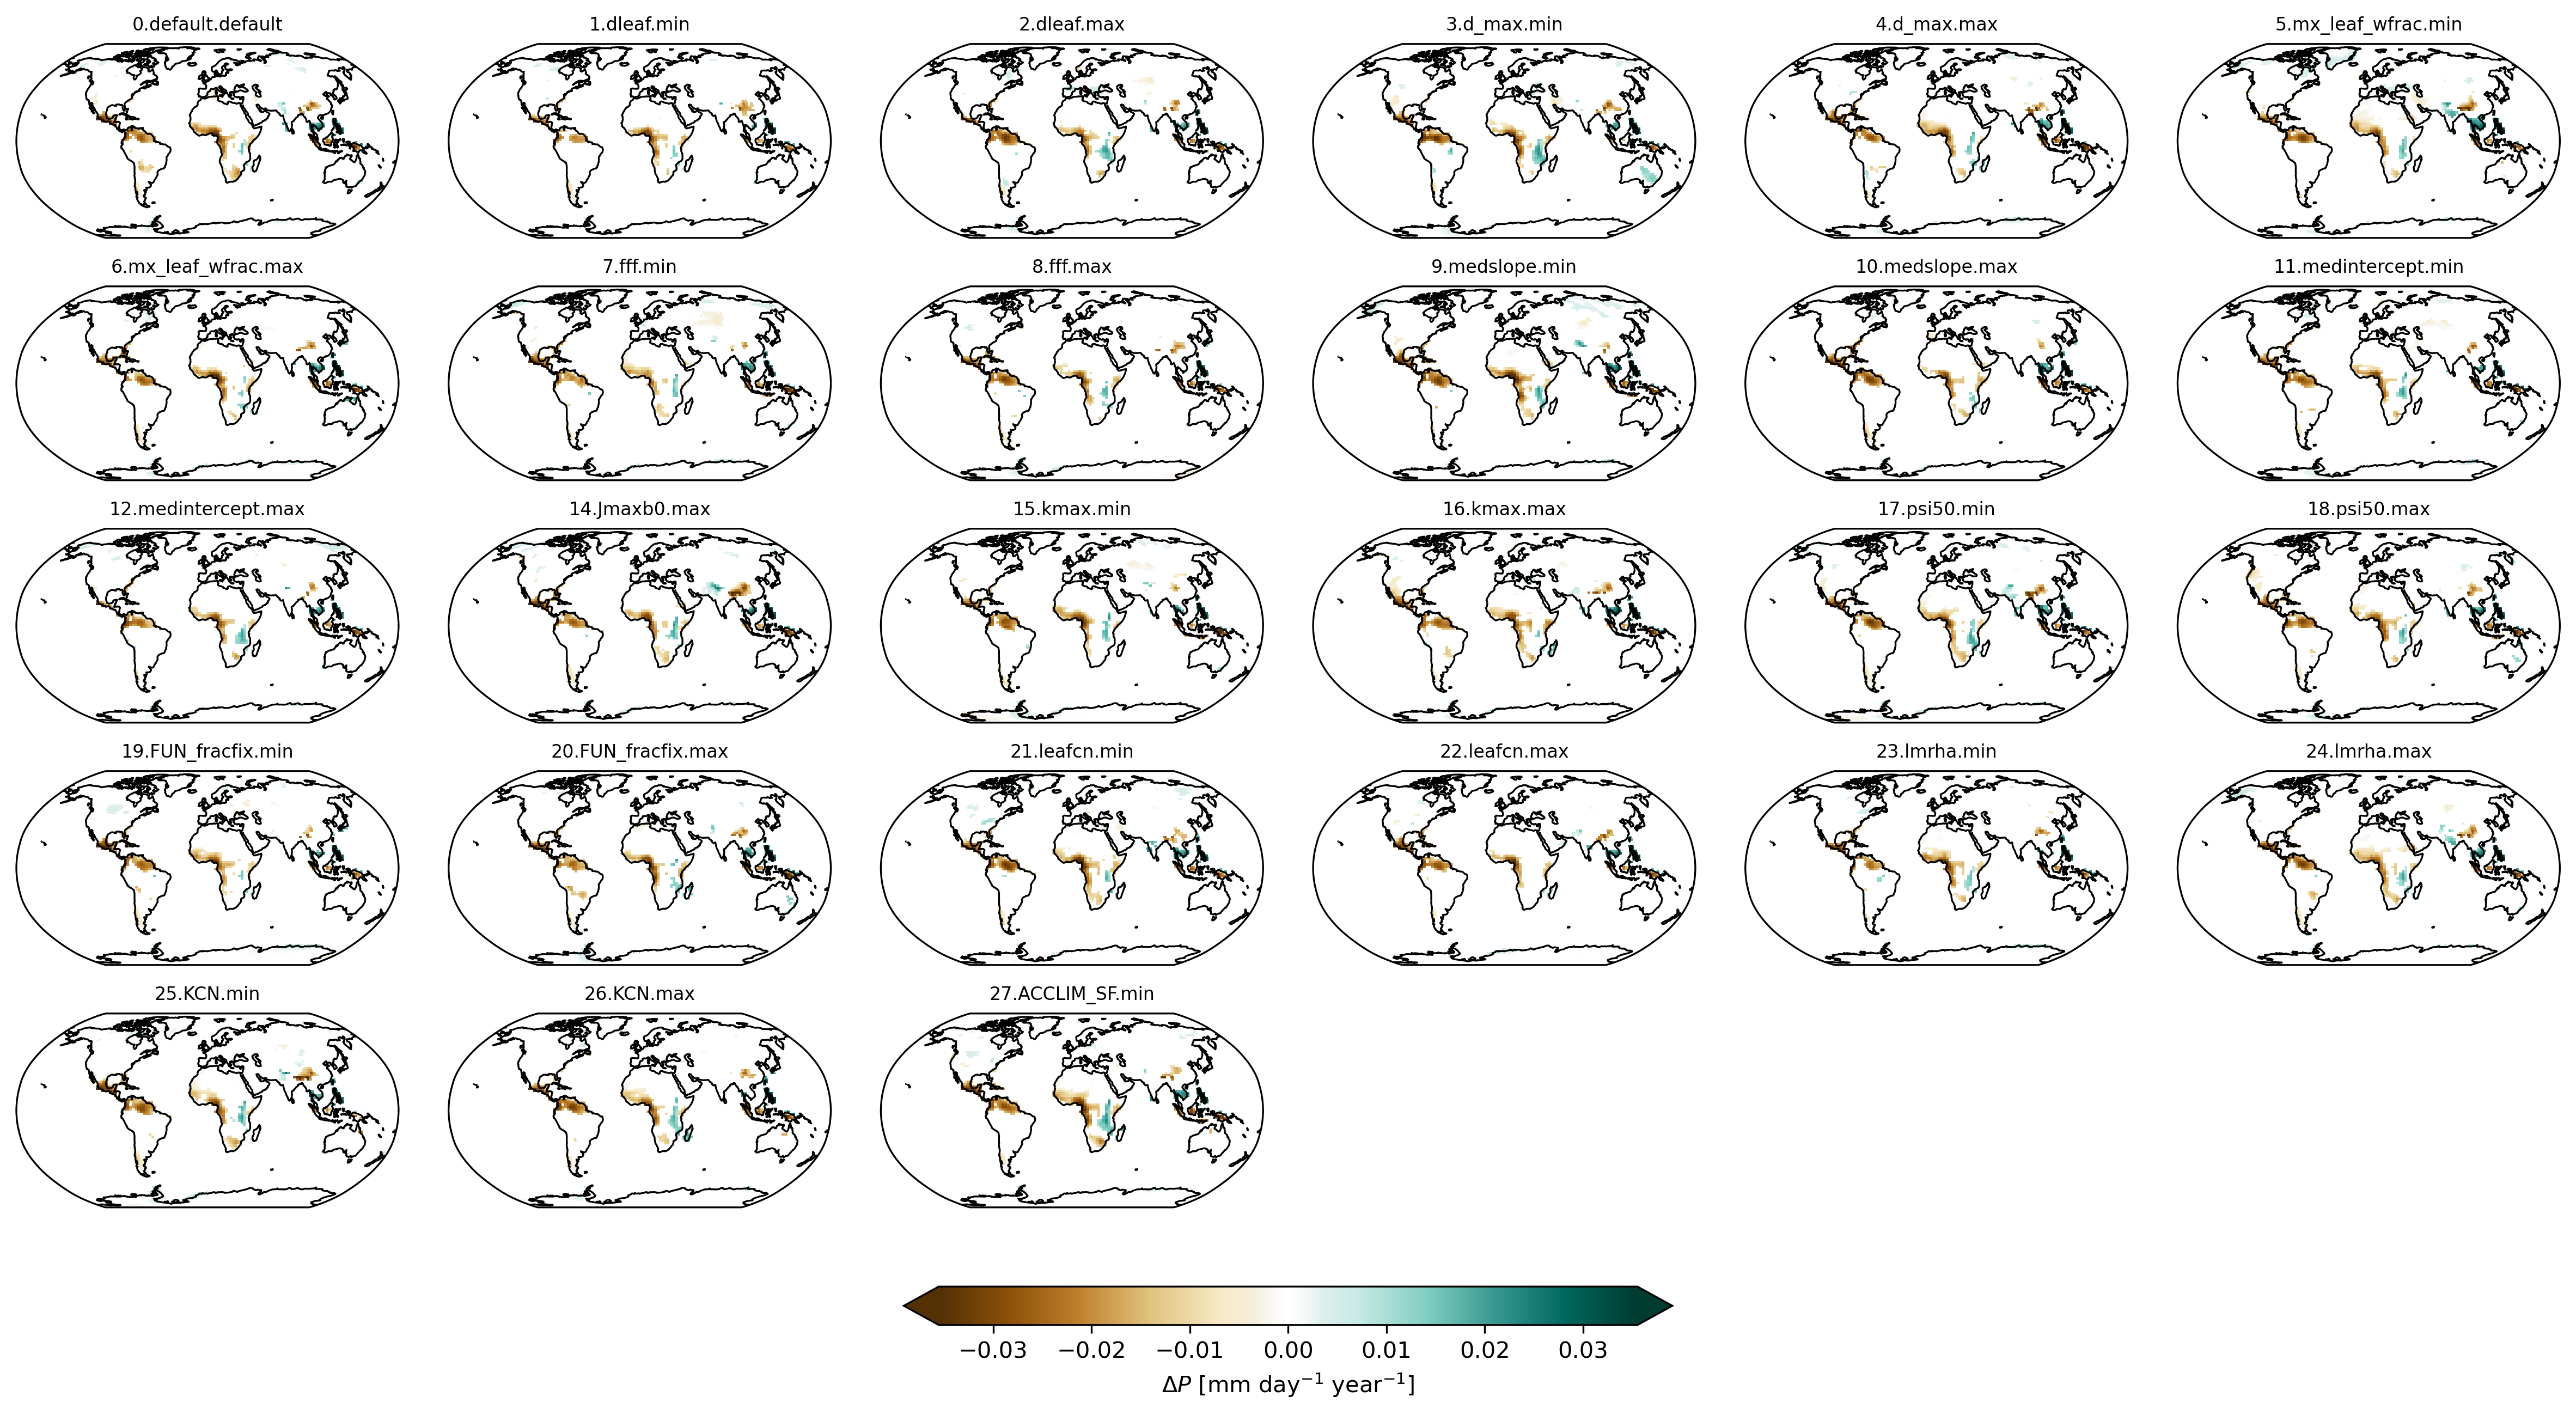

In [ ]:
fg = xclim.plot.plot_facetgrid_map(pr_dsc_ols.slope_fdr_masked, dim='member', label='$\\Delta P$ [mm day$^{-1}$ year$^{-1}$]', cmap=brbg, robust=True)
fg.fig.set_dpi(300)